In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)


Found 70296 files belonging to 38 classes.


### Validation Image Preproessing

In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [7]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set :
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[129.5  121.5  132.5 ]
   [133.   125.   136.  ]
   [135.   127.   138.  ]
   ...
   [ 72.    64.    75.  ]
   [ 69.75  61.75  72.75]
   [ 73.25  65.25  76.25]]

  [[134.5  126.5  137.5 ]
   [143.   135.   146.  ]
   [137.   129.   140.  ]
   ...
   [ 70.    62.    73.  ]
   [ 73.25  65.25  76.25]
   [ 68.25  60.25  71.25]]

  [[140.25 132.25 143.25]
   [140.25 132.25 143.25]
   [133.75 125.75 136.75]
   ...
   [ 70.    62.    73.  ]
   [ 69.5   61.5   72.5 ]
   [ 67.75  59.75  70.75]]

  ...

  [[152.5  143.5  146.5 ]
   [153.75 144.75 147.75]
   [155.   146.   149.  ]
   ...
   [114.25 105.25 110.25]
   [115.5  106.5  111.5 ]
   [117.   108.   113.  ]]

  [[147.75 138.75 141.75]
   [149.75 140.75 143.75]
   [152.   143.   146.  ]
   ...
   [111.25 102.25 107.25]
   [113.25 104.25 109.25]
   [115.   106.   111.  ]]

  [[149.5  140.5  143.5 ]
   [147.25 138.25 141.25]
   [148.25 139.25 142.25]
   ...
   [113.25 104.25 109.25]
   [112.5  103.5  108.5 ]
   [116.   107.   11

### To avoid Overshooting
1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting , so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibility that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [65]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [67]:
model = Sequential()

## Building Convolution Layer

In [69]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128, 128, 3]))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [71]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [73]:
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [75]:
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [77]:
model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [79]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [81]:
model.add(Flatten())

In [83]:
model.add(Dense(units=1500, activation='relu'))

In [85]:
model.add(Dropout(0.4))

In [87]:
#Output Layer
model.add(Dense(units=38, activation='softmax'))

### Compiling Model

In [89]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [91]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [93]:
training_history = model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2245s 1s/step - accuracy: 0.4240 - loss: 2.0341 - val_accuracy: 0.8378 - val_loss: 0.5138
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 5197s 2s/step - accuracy: 0.8448 - loss: 0.4977 - val_accuracy: 0.9043 - val_loss: 0.2965
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4092s 2s/step - accuracy: 0.9065 - loss: 0.2887 - val_accuracy: 0.9294 - val_loss: 0.2199
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2611s 1s/step - accuracy: 0.9363 - loss: 0.1971 - val_accuracy: 0.9450 - val_loss: 0.1666
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2211s 1s/step - accuracy: 0.9515 - loss: 0.1474 - val_accuracy: 0.9517 - val_loss: 0.1476
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1792s 815ms/step - accuracy: 0.9642 - loss: 0.1088 - val_accuracy: 0.9622 - val_loss: 0.1192
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2056s 936ms/step - accuracy: 0.9675 - loss: 0.0969 - val_accuracy: 0.9626 - val_loss: 0.1234
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 11111s 5s/step - accuracy: 0

## Model Evaluation

In [96]:
#Modle Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 480s 219ms/step - accuracy: 0.9920 - loss: 0.0244


In [99]:
print(train_loss, train_acc)

0.02315351739525795 0.9924888014793396


In [101]:
#Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 112s 203ms/step - accuracy: 0.9687 - loss: 0.1002


### Saving Model

In [105]:
model.save("trained_model.keras")

In [107]:
training_history.history

{'accuracy': [0.6206558346748352,
  0.8643146753311157,
  0.9148445725440979,
  0.9391137361526489,
  0.9541361331939697,
  0.9662564992904663,
  0.9700689911842346,
  0.9757735133171082,
  0.9786186814308167,
  0.9810939431190491],
 'loss': [1.2833865880966187,
  0.4290626049041748,
  0.2638509273529053,
  0.18662723898887634,
  0.1389336735010147,
  0.10186036676168442,
  0.08964696526527405,
  0.07572082430124283,
  0.06506124138832092,
  0.058565396815538406],
 'val_accuracy': [0.8378101587295532,
  0.9043364524841309,
  0.9293763041496277,
  0.9449692964553833,
  0.9517413973808289,
  0.9622126221656799,
  0.9626109600067139,
  0.9536762833595276,
  0.9465057849884033,
  0.9689278602600098],
 'val_loss': [0.5137995481491089,
  0.2965496778488159,
  0.21986758708953857,
  0.16664385795593262,
  0.147640660405159,
  0.11919526755809784,
  0.12336193025112152,
  0.15373779833316803,
  0.1903424859046936,
  0.10496681183576584]}

In [109]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history, f)

### Accuracy Visualization

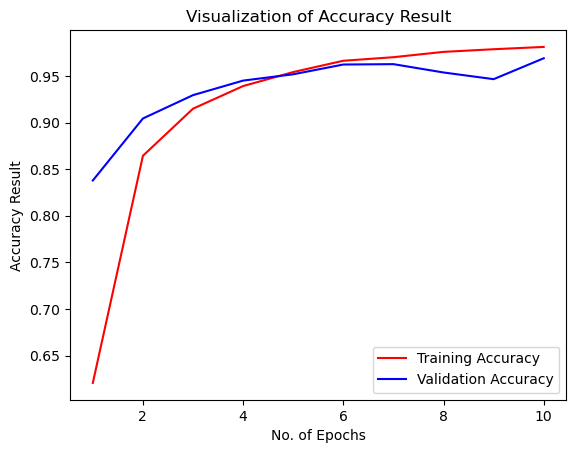

In [120]:
epochs = [i for i in range(1, 11)]
plt.plot(epochs, training_history.history['accuracy'], color="red", label="Training Accuracy")
plt.plot(epochs, training_history.history['val_accuracy'], color="blue", label="Validation Accuracy")
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [123]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [125]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [129]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 116s 211ms/step


(array([[1.0000000e+00, 1.8000613e-10, 7.6342808e-14, ..., 2.0221325e-20,
         6.9431602e-20, 3.4028968e-18],
        [1.0000000e+00, 4.6082731e-11, 3.3668947e-12, ..., 3.2247770e-16,
         6.3871552e-17, 2.2712272e-15],
        [1.0000000e+00, 1.3450834e-10, 2.3484131e-13, ..., 3.0179935e-21,
         3.3503040e-19, 1.1972035e-16],
        ...,
        [4.5254096e-12, 3.2175529e-15, 1.2854321e-11, ..., 2.4558111e-14,
         1.5023769e-13, 1.0000000e+00],
        [3.1845819e-12, 4.6583334e-16, 2.0889341e-12, ..., 3.2318545e-14,
         4.9051834e-14, 1.0000000e+00],
        [3.9209752e-15, 6.6696698e-17, 3.7891354e-15, ..., 4.1015165e-17,
         4.1936174e-14, 9.9999976e-01]], dtype=float32),
 (17572, 38))

In [131]:
predicted_categories = tf.argmax(y_pred, axis=1) 

In [133]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [135]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [137]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

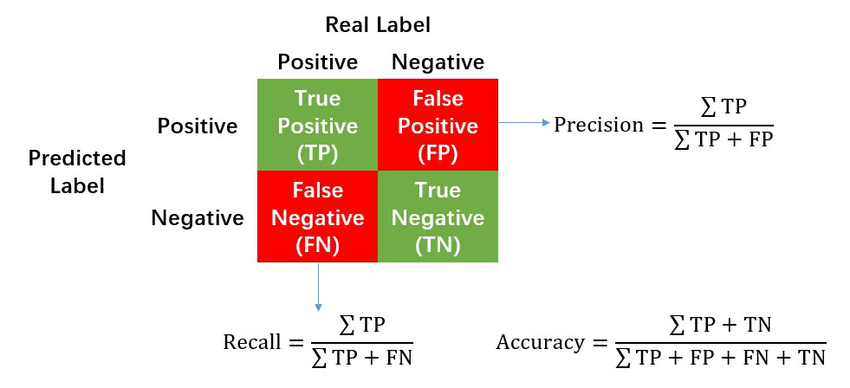

In [147]:
from sklearn.metrics import classification_report, confusion_matrix

In [145]:
print(classification_report(Y_true, predicted_categories, target_names = class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.98      0.96       504
                                 Apple___Black_rot       0.98      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.96      0.98       440
                                   Apple___healthy       0.97      0.96      0.97       502
                               Blueberry___healthy       0.98      0.97      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.98      0.94       410
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.94      0.

In [159]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[492,   0,   0, ...,   0,   0,   0],
       [  1, 493,   0, ...,   0,   0,   0],
       [  2,   0, 424, ...,   1,   0,   1],
       ...,
       [  0,   0,   0, ..., 484,   0,   0],
       [  0,   0,   0, ...,   0, 448,   0],
       [  0,   0,   0, ...,   0,   0, 471]], dtype=int64)

### Confusion Matrix Visualization

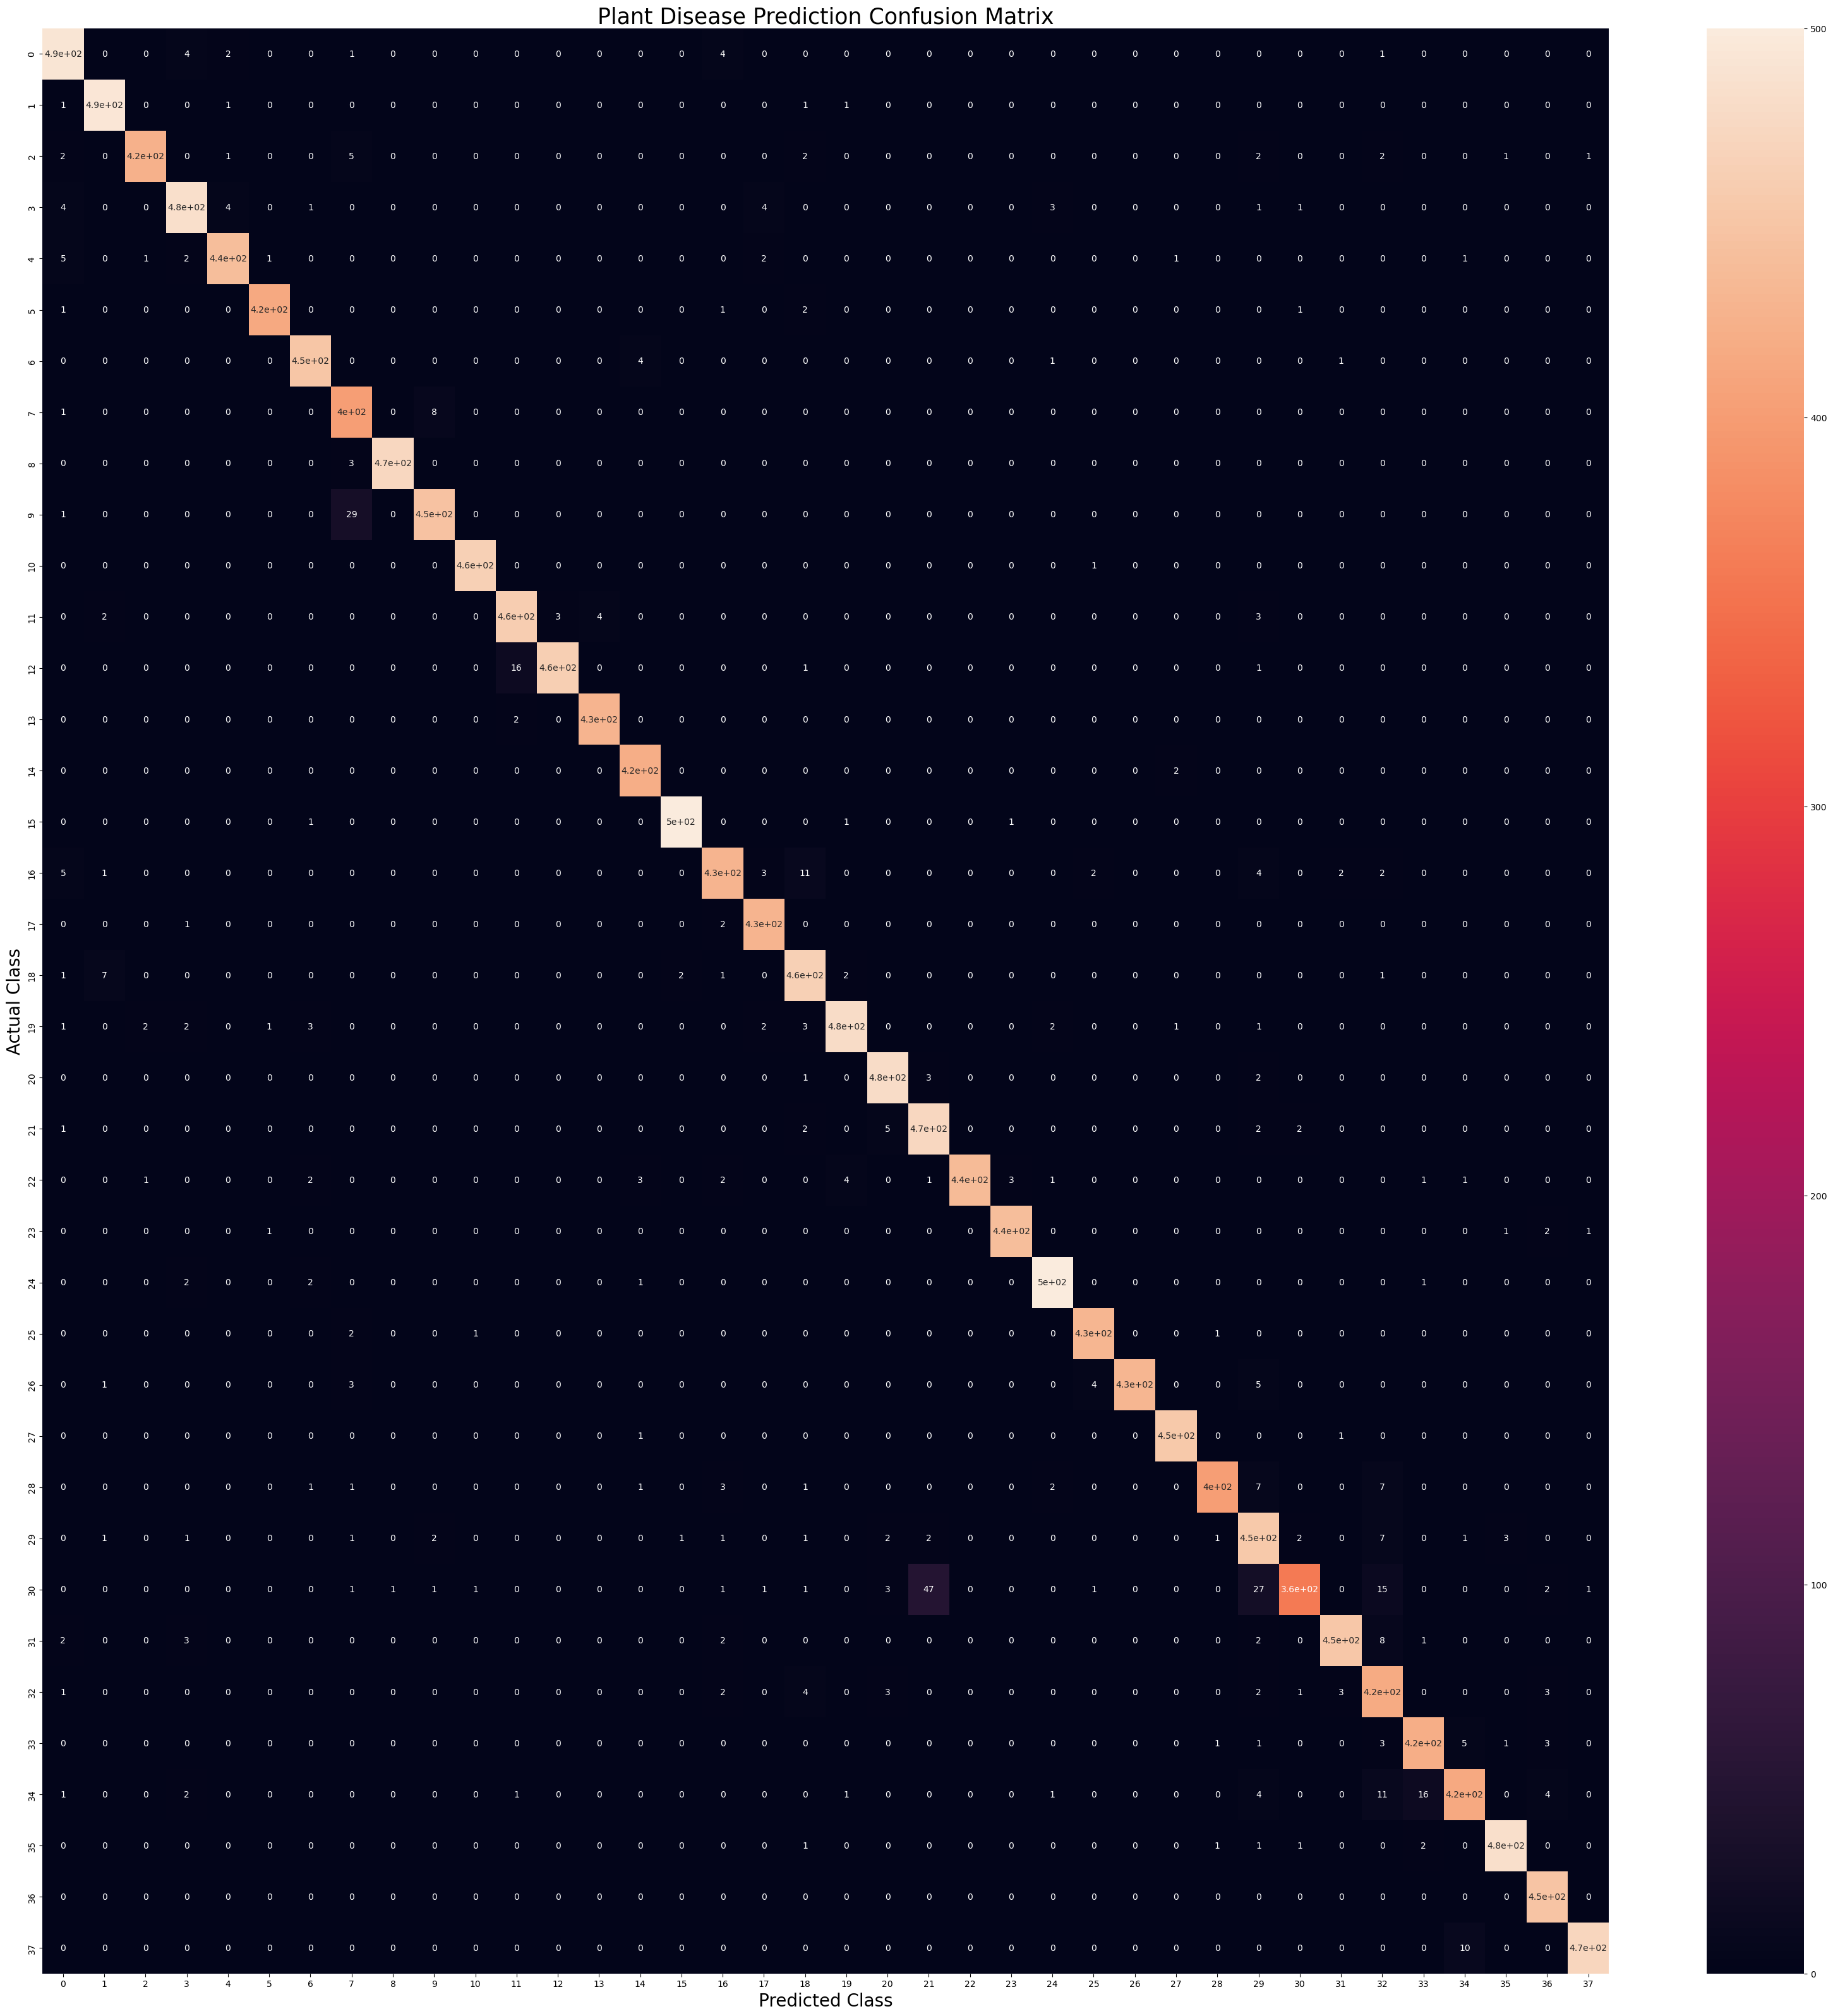

In [176]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm, annot=True, annot_kws={'size':10})
plt.xlabel("Predicted Class", fontsize=20)
plt.ylabel("Actual Class", fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=25)
plt.show()